### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [38]:
data.shape

(12684, 26)

In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [40]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

The dataset contains 12,684 observations and 26 columns. I checked for missing values and found that the car column is missing data for almost every observation. There are also smaller numbers of missing values in the Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 columns. The remaining columns do not contain missing values.

3. Decide what to do about your missing data -- drop, replace, other...

In [41]:
data_clean = data.drop(columns=['car'])

In [42]:
data_clean = data_clean.dropna()

In [43]:
data_clean.shape

(12079, 25)

In [44]:
data_clean.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

I removed the car column because 12,576 of its 12,684 values were missing, making the column unsuitable for analysis. I then removed the rows containing missing values in the remaining columns. After cleaning, the dataset contains 12,079 observations and 25 columns. This preserves most of the original dataset while ensuring that the following calculations use complete observations.

4. What proportion of the total observations chose to accept the coupon?



In [49]:
acceptance_percentage = data["Y"].mean() * 100

print(f"Percentage who accepted the coupon: {acceptance_percentage:.2f}%")

Percentage who accepted the coupon: 56.84%


5. Use a bar plot to visualize the `coupon` column.

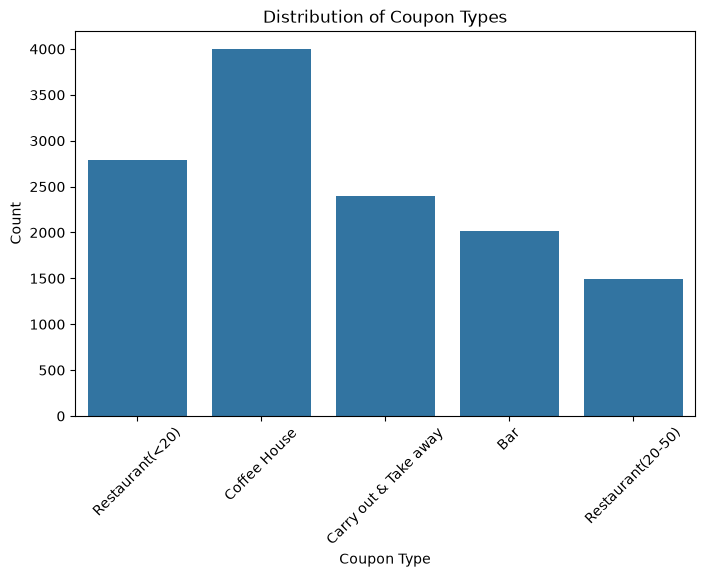

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,5))
sns.countplot(data=data, x = 'coupon')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

The bar chart shows the number of observations for each coupon type. Coffee House and Restaurant coupons appear the most, while Carry Out & Take Away coupons appear less often.

6. Use a histogram to visualize the temperature column.

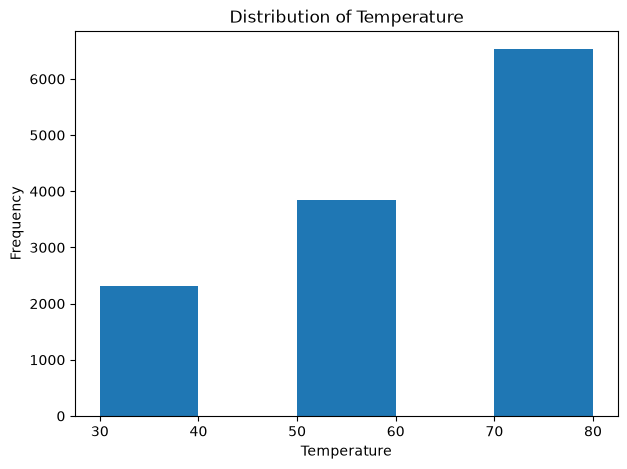

In [51]:
plt.figure(figsize=(7,5))
plt.hist(data['temperature'], bins=5)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

The histogram shows that the survey was conducted at only a few temperature values (30°F, 55°F, and 80°F). The most common temperature in the dataset is 80°F.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [16]:
bar_df = data[data['coupon'] == 'Bar']

bar_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [17]:
bar_acceptance = bar_df['Y'].mean()

print(f'Acceptance rate: {bar_acceptance:.2%}')

Acceptance rate: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [53]:
three_or_less = bar_df[
    bar_df['Bar'].isin(['never', 'less1', '1-3'])
]

more_than_three = bar_df[
    bar_df['Bar'].isin(['4-8', 'gt8'])
]

print("3 or fewer times:")
print(three_or_less['Y'].mean())

print("More than 3 times:")
print(more_than_three['Y'].mean())

3 or fewer times:
0.29214285714285715
More than 3 times:
0.7346938775510204


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [54]:
more_than_once = ['1-3','4-8','gt8']

group1 = bar_df[
    (bar_df['Bar'].isin(more_than_once)) &
    (bar_df['age'] != 'below21') &
    (bar_df['age'] != '21')
]

group2 = bar_df.drop(group1.index)

print("Group 1:", group1['Y'].mean())
print("Others:", group2['Y'].mean())

Group 1: 0.7
Others: 0.40563663814796175


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [57]:
bar_visits = bar_df["Bar"].isin(more_than_once)

no_kids = bar_df["passanger"] != "Kid(s)"

not_farming = ~bar_df["occupation"].isin(["Farming Fishing & Forestry"])

group = bar_df[bar_visits & no_kids & not_farming]

acceptance_rate = group["Y"].mean()

print(f"Acceptance Rate: {acceptance_rate:.2%}")

Acceptance Rate: 72.92%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [58]:
bar_visits = bar_df["Bar"].isin(more_than_once)

no_kids = bar_df["passanger"] != "Kid(s)"

not_widowed = bar_df["maritalStatus"] != "Widowed"

group1 = bar_df[bar_visits & no_kids & not_widowed]

group1_acceptance = group1["Y"].mean()

print(f"Group 1 Acceptance Rate: {group1_acceptance:.2%}")

Group 1 Acceptance Rate: 72.92%


In [59]:
bar_visits = bar_df["Bar"].isin(more_than_once)

under_30 = bar_df["age"].isin(["below21", "21", "26"])

group2 = bar_df[bar_visits & under_30]

group2_acceptance = group2["Y"].mean()

print(f"Group 2 Acceptance Rate: {group2_acceptance:.2%}")

Group 2 Acceptance Rate: 81.08%


In [60]:
frequent_restaurants = bar_df["RestaurantLessThan20"].isin(["4~8", "gt8"])

lower_income = bar_df["income"].isin([
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
])

group3 = bar_df[frequent_restaurants & lower_income]

group3_acceptance = group3["Y"].mean()

print(f"Group 3 Acceptance Rate: {group3_acceptance:.2%}")

Group 3 Acceptance Rate: 45.35%


In [61]:
print("Group 1:", group1['Y'].mean())
print("Group 2:", group2['Y'].mean())
print("Group 3:", group3['Y'].mean())

Group 1: 0.7291666666666666
Group 2: 0.8108108108108109
Group 3: 0.45348837209302323


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on these observations, I hypothesize that drivers who regularly visit bars are much more likely to accept bar coupons than those who don't really visit bars. Drivers who visited bars more than three times a month had an acceptance rate of 73%, compared to only 29% for those who visited bars fewer than three times per month. Drivers who visited bars more than once a month and were under the age of 30 had the highest acceptance rate at 81%, suggesting that younger people who go to bars are the most likely to use the bar coupons. Drivers who went to bars, were not traveling with children, and were not widowed also had a high acceptance rate at 73%. However, drivers who frequently visited cheaper restaurants and had an income below $50,000 had a lower acceptance rate of about 45%. In conclusion, these results suggest that a person's bar going behavior is the strongest indicator to whether they would accept a bar coupon or not. Age and some social constructs also seem to influence acceptance behavior.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [25]:
restaurant_df = data[data["coupon"] == "Restaurant(<20)"]

restaurant_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
5,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
7,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
10,No Urgent Place,Kid(s),Sunny,80,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
11,No Urgent Place,Kid(s),Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1


In [26]:
restaurant_acceptance = restaurant_df["Y"].mean()

print(f"Acceptance Rate: {restaurant_acceptance:.2%}")

Acceptance Rate: 70.71%


In [27]:
income_acceptance = restaurant_df.groupby("income")["Y"].mean().sort_values()

income_acceptance

income
$87500 - $99999     0.577889
$75000 - $87499     0.661458
$37500 - $49999     0.681818
$12500 - $24999     0.685000
$62500 - $74999     0.696809
$100000 or More     0.717678
Less than $12500    0.724138
$25000 - $37499     0.753363
$50000 - $62499     0.782486
Name: Y, dtype: float64

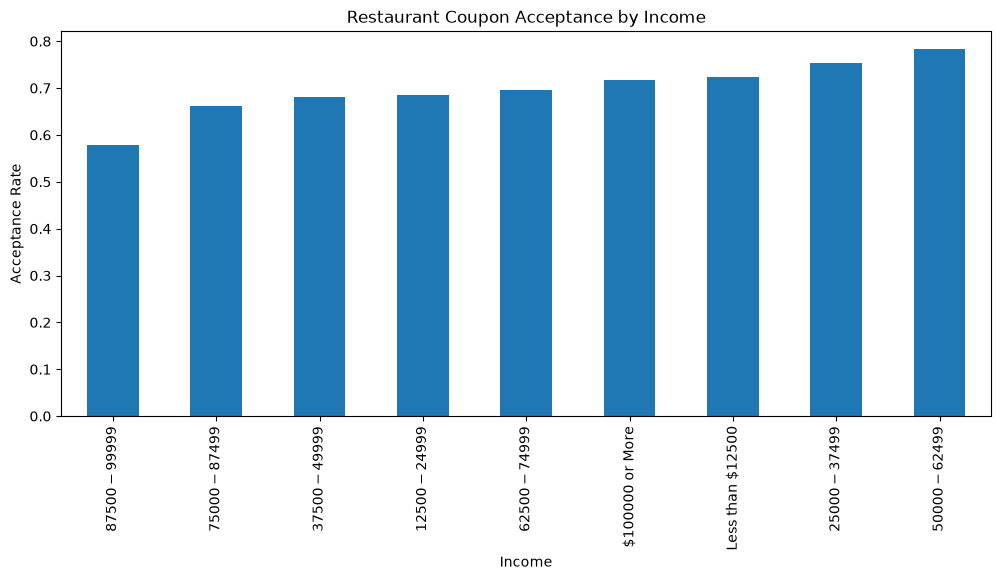

In [62]:
plt.figure(figsize=(12,5))

income_acceptance.plot(kind="bar")
plt.title("Restaurant Coupon Acceptance by Income")
plt.xlabel("Income")
plt.ylabel("Acceptance Rate")

plt.show()

In [30]:
destination_acceptance = restaurant_df.groupby("destination")["Y"].mean()

destination_acceptance

destination
Home               0.555332
No Urgent Place    0.792541
Work               0.582897
Name: Y, dtype: float64

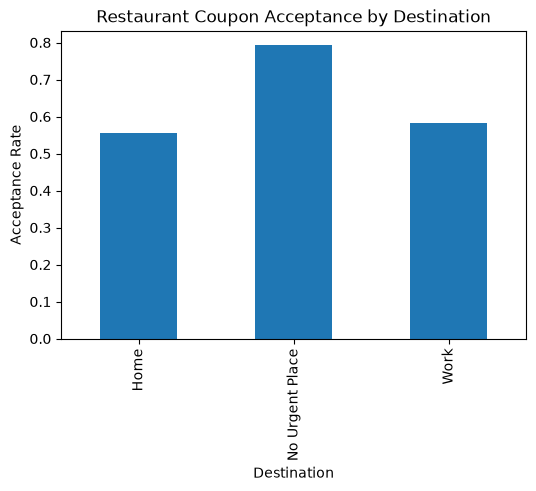

In [31]:
plt.figure(figsize=(6,4))

destination_acceptance.plot(kind="bar")

plt.title("Restaurant Coupon Acceptance by Destination")
plt.xlabel("Destination")
plt.ylabel("Acceptance Rate")

plt.show()

In [32]:
time_acceptance = restaurant_df.groupby("time")["Y"].mean()

time_acceptance

time
10AM    0.709571
10PM    0.505376
2PM     0.813486
6PM     0.827540
7AM     0.582897
Name: Y, dtype: float64

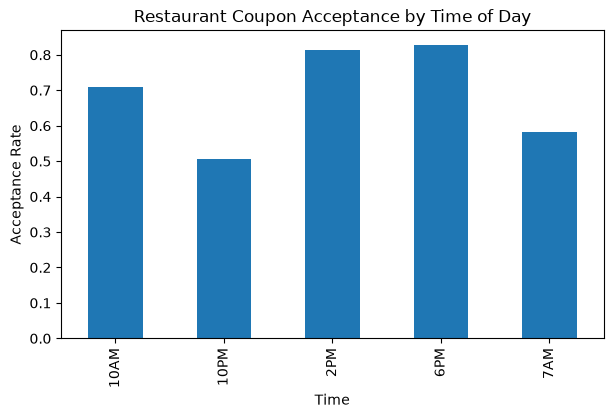

In [33]:
plt.figure(figsize=(7,4))

time_acceptance.plot(kind="bar")

plt.title("Restaurant Coupon Acceptance by Time of Day")
plt.xlabel("Time")
plt.ylabel("Acceptance Rate")

plt.show()

In [63]:
age_acceptance = restaurant_df.groupby("age")["Y"].mean()
age_acceptance

age
21         0.741652
26         0.730838
31         0.705357
36         0.651877
41         0.708502
46         0.756757
50plus     0.637755
below21    0.734375
Name: Y, dtype: float64

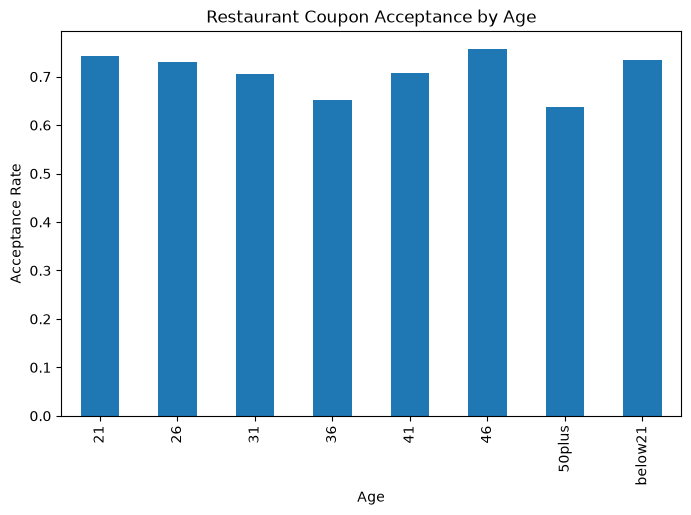

In [64]:
plt.figure(figsize=(8,5))

age_acceptance.plot(kind="bar")

plt.title("Restaurant Coupon Acceptance by Age")
plt.xlabel("Age")
plt.ylabel("Acceptance Rate")
plt.show()

In [36]:
passenger_acceptance = restaurant_df.groupby("passanger")["Y"].mean()

passenger_acceptance

passanger
Alone        0.638328
Friend(s)    0.801453
Kid(s)       0.722846
Partner      0.771318
Name: Y, dtype: float64

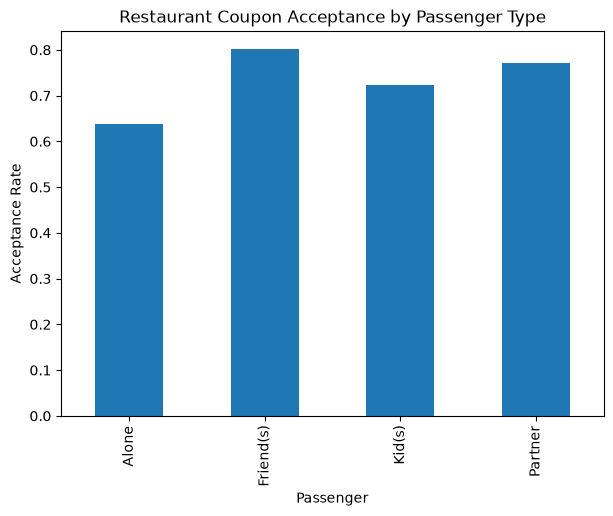

In [37]:
plt.figure(figsize=(7,5))

passenger_acceptance.plot(kind="bar")

plt.title("Restaurant Coupon Acceptance by Passenger Type")
plt.xlabel("Passenger")
plt.ylabel("Acceptance Rate")

plt.show()

Summary
This explored the characteristics of drivers who accepted Restaurant coupons. The analysis compared coupon acceptance across several  characteristics : income, destination, time of day, age, and passenger type. The visualizations showed that acceptance rates varied among these groups. Showing that customer demographics and the context of the trip influences a person's acceptance of a restaurant coupon.

I would say restaurant coupons appear to be more successful when offered to drivers whose travel plans and personal characteristics align with dining opportunities. If it is conviennt to the driver, it will have a higher chance of being used. These show that to get more people to use coupons they should target promotions based on demographics and driving data. 